In [44]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

(1000, 2000)
cells shape:  (50, 100, 20, 20)
train shape:  (5000, 400)


True

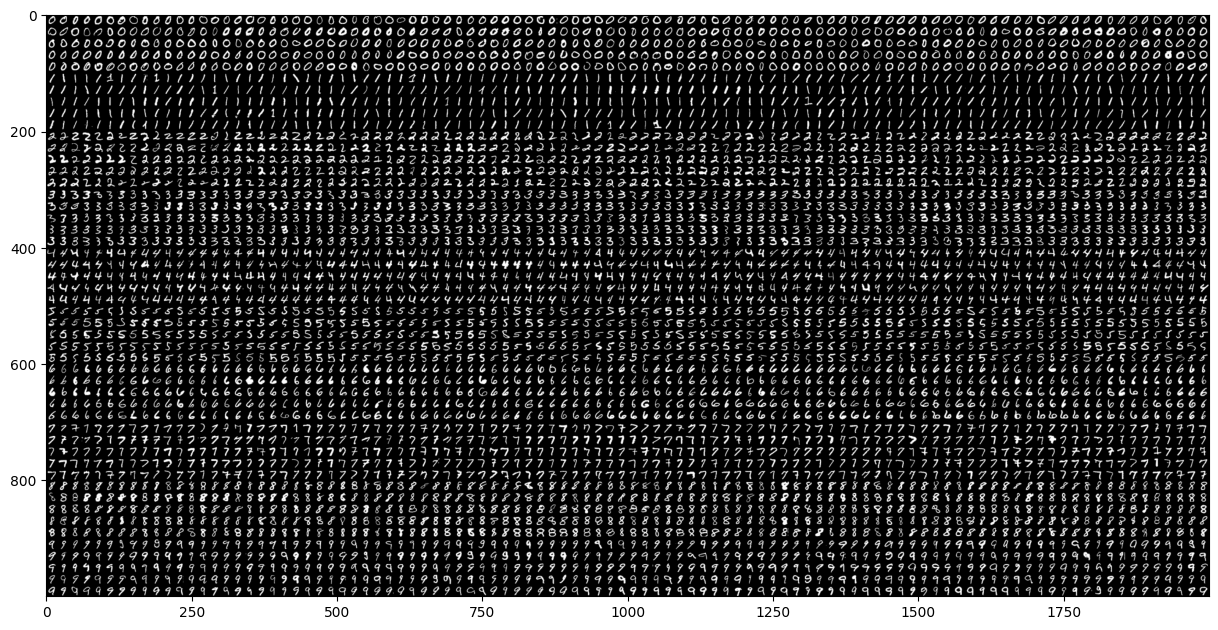

In [45]:
img = cv2.imread('/Users/hadisasadi/Documents/OpenCV/class.vision-master1/class.vision-master/dataset/digits.png', 0)
print(img.shape)
plt.figure(figsize=[15,30])
plt.imshow(img, cmap='gray')

# Now we split the image to 5000 cells, each 20x20 size
cells = [np.hsplit(row,100) for row in np.vsplit(img,50)]
cells = np.array(cells)
print("cells shape: ", cells.shape)
# Use the full dataset for training
train = cells.reshape(-1,400).astype(np.float32)
print("train shape: ", train.shape)

# Create labels for the full training dataset
k = np.arange(10)
train_labels = np.repeat(k,500)[:,np.newaxis]

# Initiate kNN and train on the full dataset
knn = cv2.ml.KNearest_create()
knn.train(train, cv2.ml.ROW_SAMPLE, train_labels)

(<Axes: title={'center': 'Plate'}>,
 Text(0.5, 1.0, 'Plate'))

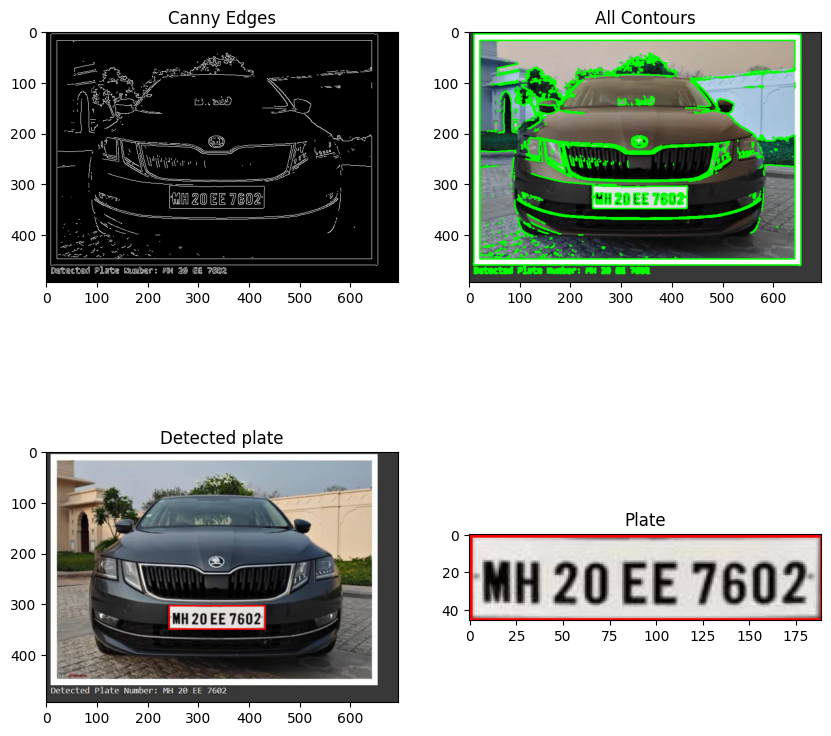

In [46]:
img = cv2.imread("./Screenshot-2025-03-24-173929_webp.png.jpeg")

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

edges = cv2.Canny(gray, 230, 255)

contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE) 
all_contours = cv2.drawContours(img.copy(), contours, -1, (0,255,0), 2)  

for contour in contours:
    area = cv2.contourArea(contour)
    if area < 10000 and area > 600:
        x, y, w, h = cv2.boundingRect(contour)
        cv2.rectangle(img, (x, y), (x + w, y + h), (0,0 ,255), 2)
        plate = img[y:y+h, x:x+w]
        

plt.figure(figsize=(10,10))
plt.subplot(221);plt.imshow(edges, cmap='gray');plt.title('Canny Edges')
plt.subplot(222 ),plt.imshow(all_contours, cmap='gray'),plt.title('All Contours')
plt.subplot(223),plt.imshow(img[...,::-1]),plt.title('Detected plate')
plt.subplot(224),plt.imshow(plate[...,::-1]),plt.title('Plate')


In [47]:
def x_cord_contour(contour):
    M = cv2.moments(contour)
    if M['m00'] != 0:
        return int(M['m10'] / M['m00'])
    return float('inf')

Number of contours in the plate: 15


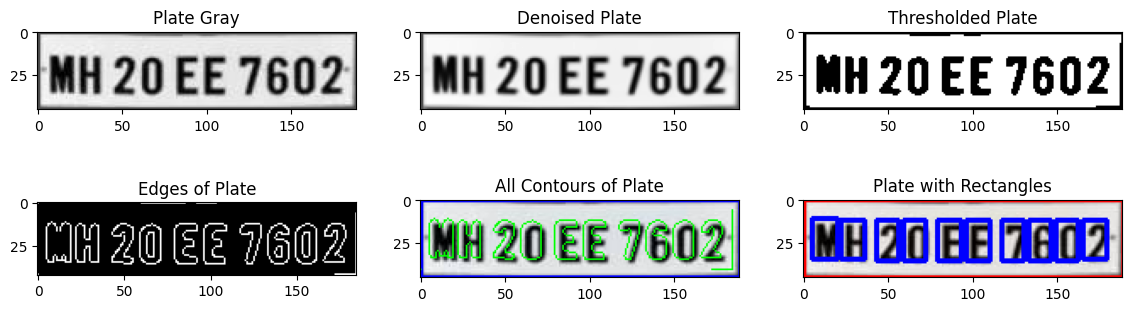

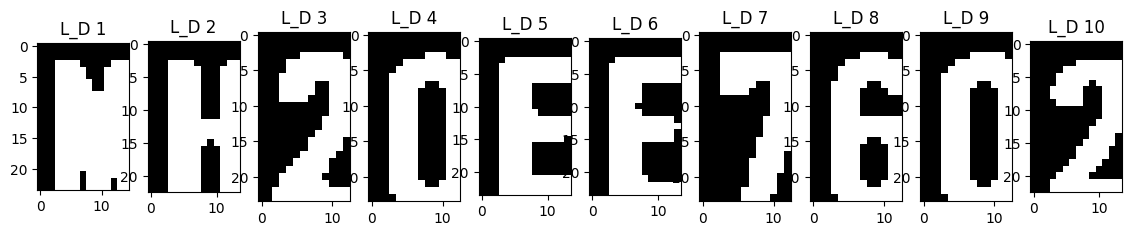

In [56]:
plate_gray = cv2.cvtColor(plate, cv2.COLOR_BGR2GRAY)

plate_denoise = cv2.fastNlMeansDenoising(plate_gray, None, 30, 7, 21)

_, plate_thresh = cv2.threshold(plate_denoise, 150, 255, cv2.THRESH_BINARY)

edges_plate = cv2.Canny(plate_thresh, 100, 200)

# delete borders of the plate
edges_plate = edges_plate[2:-2, 2:-2]

contours_plate, _ = cv2.findContours(edges_plate, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
all_contours_plate = cv2.drawContours(plate.copy(), contours_plate, -1, (0,255,0), 1)


letters_digits = []

contours_left_to_right = sorted(contours_plate, key=x_cord_contour)

plate_with_rectangles = plate.copy()

for c in contours_left_to_right:
    area = cv2.contourArea(c)
    if 5 < area < 400:
        x, y, w, h = cv2.boundingRect(c)
        cv2.rectangle(plate_with_rectangles, (x, y), (x + w, y + h), (255,0 ,0), 2)
        letter = plate[y:y+h, x:x+w]
        letters_digits.append(letter)
        
print(f"Number of contours in the plate: {len(contours_plate)}")

plt.figure(figsize=(14,4))
plt.subplot(231),plt.imshow(plate_gray, cmap='gray'),plt.title('Plate Gray')
plt.subplot(232),plt.imshow(plate_denoise, cmap='gray'),plt.title('Denoised Plate')
plt.subplot(233),plt.imshow(plate_thresh, cmap='gray'),plt.title('Thresholded Plate')
plt.subplot(234),plt.imshow(edges_plate, cmap='gray'),plt.title('Edges of Plate')
plt.subplot(235),plt.imshow(all_contours_plate, cmap='gray'),plt.title('All Contours of Plate')
plt.subplot(236),plt.imshow(plate_with_rectangles[...,::-1]),plt.title('Plate with Rectangles')

letters_digits_thr=[]
plt.figure(figsize=(14,4))
for i, l_d in enumerate(letters_digits):
    _, l_d_thr = cv2.threshold(cv2.cvtColor(l_d, cv2.COLOR_BGR2GRAY), 150, 255, cv2.THRESH_BINARY_INV)
    letters_digits_thr.append(l_d_thr)
    plt.subplot(1, len(letters_digits), i+1),plt.imshow(l_d_thr, cmap='gray'),plt.title(f'L_D {i+1}')


In [57]:
digits = [letters_digits_thr[2], letters_digits_thr[3], letters_digits_thr[6], letters_digits_thr[7], letters_digits_thr[8], letters_digits_thr[9]]
resize_digits = []
for digit in digits:
    digit_resize = cv2.resize(digit, (20, 20))
    digit_blur = cv2.GaussianBlur(digit_resize, (3, 3), 0)

    resize_digits.append(digit_blur.reshape(1,400).astype(np.float32))

resize_digits = np.vstack(resize_digits)
resize_digits.shape

(6, 400)

Predicted digits:  [0. 5. 0. 8. 8. 0.]


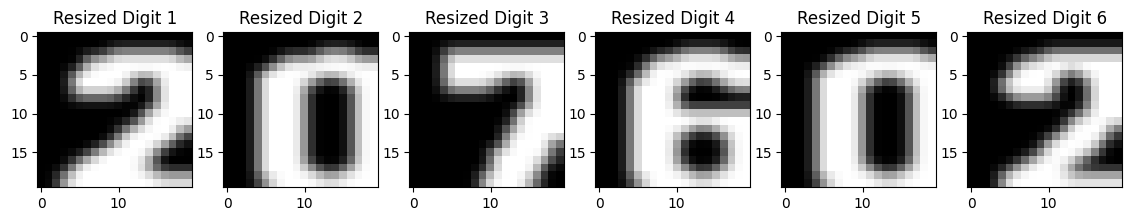

In [58]:
plt.figure(figsize=(14,4))
for i ,d in enumerate(resize_digits):
    plt.subplot(1, len(resize_digits), i+1),plt.imshow(d.reshape(20,20), cmap='gray'),plt.title(f'Resized Digit {i+1}')

ret, results, neighbours, dist = knn.findNearest(resize_digits, k=5)
print("Predicted digits: ", results.ravel())
